# MyDataInsight — CSV 탐색적 데이터 분석 (EDA)

CSV 파일을 업로드하면 **데이터 개요**, **EDA(탐색적 데이터 분석)**, **시각화**를 자동으로 수행합니다.

> 참고 데이터: `vive_0620_data(100)_CustomerChurn(Marketing).csv` (고객 이탈 마케팅 데이터)

## 1. 라이브러리 설치 및 임포트

In [1]:
%pip install pandas numpy matplotlib seaborn ipywidgets -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import io
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

try:
    import ipywidgets as widgets
    from IPython.display import clear_output
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", palette="muted")

print("라이브러리 로드 완료")

라이브러리 로드 완료


## 2. CSV 파일 업로드

아래 **파일 업로드 버튼**으로 CSV를 선택하거나, 기본 참고 데이터 경로를 그대로 사용할 수 있습니다.

In [ ]:
DEFAULT_CSV = Path("vive_0620_data(100)_CustomerChurn(Marketing).csv")
uploaded_df = None
uploaded_filename = None


def load_csv_from_bytes(content: bytes, filename: str) -> pd.DataFrame:
    """업로드된 바이트 데이터를 DataFrame으로 변환합니다."""
    for encoding in ("utf-8", "cp949", "euc-kr", "latin-1"):
        try:
            return pd.read_csv(io.BytesIO(content), encoding=encoding, sep=None, engine="python")
        except UnicodeDecodeError:
            continue
    raise ValueError(f"{filename}: 지원되는 인코딩으로 파일을 읽을 수 없습니다.")


def load_csv_from_path(path: Path) -> pd.DataFrame:
    """로컬 경로의 CSV를 DataFrame으로 로드합니다."""
    if not path.exists():
        raise FileNotFoundError(f"파일을 찾을 수 없습니다: {path}")
    for encoding in ("utf-8", "cp949", "euc-kr", "latin-1"):
        try:
            return pd.read_csv(path, encoding=encoding, sep=None, engine="python")
        except UnicodeDecodeError:
            continue
    raise ValueError(f"{path}: 지원되는 인코딩으로 파일을 읽을 수 없습니다.")


if HAS_WIDGETS:
    uploader = widgets.FileUpload(accept=".csv", multiple=False, description="CSV 업로드")
    status = widgets.Output()

    def on_upload_change(change):
        global uploaded_df, uploaded_filename
        with status:
            clear_output(wait=True)
            if not uploader.value:
                return
            file_info = uploader.value[0]
            uploaded_filename = file_info["name"]
            uploaded_df = load_csv_from_bytes(file_info["content"], uploaded_filename)
            print(f"업로드 완료: {uploaded_filename} ({uploaded_df.shape[0]:,}행 × {uploaded_df.shape[1]}열)")

    uploader.observe(on_upload_change, names="value")
    display(uploader, status)
else:
    print("ipywidgets 미설치 — 아래 셀에서 DEFAULT_CSV 경로를 사용합니다.")

FileUpload(value=(), accept='.csv', description='CSV 업로드')

Output()

In [7]:
# 업로드된 파일이 있으면 사용, 없으면 기본 참고 데이터 로드
if uploaded_df is not None:
    df_raw = uploaded_df.copy()
    source_name = uploaded_filename
elif DEFAULT_CSV.exists():
    df_raw = load_csv_from_path(DEFAULT_CSV)
    source_name = DEFAULT_CSV.name
else:
    raise FileNotFoundError(
        "CSV 파일이 없습니다. 위 업로드 위젯으로 파일을 선택하거나 DEFAULT_CSV 경로를 확인하세요."
    )

print(f"데이터 소스: {source_name}")
df_raw.head()

데이터 소스: winequality-white.csv


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## 3. 데이터 전처리

In [8]:
def preprocess_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """공백 제거, 불리언 정규화 등 기본 전처리를 수행합니다."""
    df = df.copy()
    df.columns = df.columns.str.strip()

    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"nan": np.nan, "None": np.nan, "": np.nan})

    # Churn 등 True./False. 형태의 불리언 값 정규화
    for col in df.columns:
        unique_vals = set(df[col].dropna().astype(str).str.lower().unique())
        if unique_vals <= {"true", "false", "true.", "false."}:
            df[col] = (
                df[col]
                .astype(str)
                .str.lower()
                .str.replace(".", "", regex=False)
                .map({"true": True, "false": False})
            )

    return df


df = preprocess_dataframe(df_raw)
print("전처리 완료")

전처리 완료


## 4. 데이터 개요 (Overview)

In [9]:
def print_data_overview(df: pd.DataFrame, source_name: str):
    n_rows, n_cols = df.shape
    memory_mb = df.memory_usage(deep=True).sum() / 1024 ** 2

    display(Markdown(f"""
### 데이터 개요
| 항목 | 값 |
|------|----|
| 파일명 | `{source_name}` |
| 행 수 | {n_rows:,} |
| 열 수 | {n_cols} |
| 메모리 사용량 | {memory_mb:.2f} MB |
| 중복 행 | {df.duplicated().sum():,} |
"""))

    print("\n[컬럼 정보]")
    col_info = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "null_count": df.isna().sum(),
        "null_pct(%)": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(),
    })
    display(col_info)

    print("\n[데이터 미리보기 — 상위 5행]")
    display(df.head())

    print("\n[기술 통계 — 수치형 변수]")
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    if num_cols:
        display(df[num_cols].describe().T.round(3))
    else:
        print("수치형 컬럼이 없습니다.")

    print("\n[범주형 변수 요약]")
    cat_cols = df.select_dtypes(include=["object", "bool", "category"]).columns.tolist()
    for col in cat_cols:
        print(f"\n▶ {col} (고유값 {df[col].nunique()}개)")
        display(df[col].value_counts(dropna=False).head(10).to_frame("count"))


print_data_overview(df, source_name)


### 데이터 개요
| 항목 | 값 |
|------|----|
| 파일명 | `winequality-white.csv` |
| 행 수 | 4,898 |
| 열 수 | 12 |
| 메모리 사용량 | 0.45 MB |
| 중복 행 | 937 |



[컬럼 정보]


,dtype,non_null,null_count,null_pct(%),unique
fixed acidity,float64,4898,0,0.0,68
volatile acidity,float64,4898,0,0.0,125
citric acid,float64,4898,0,0.0,87
residual sugar,float64,4898,0,0.0,310
chlorides,float64,4898,0,0.0,160
free sulfur dioxide,float64,4898,0,0.0,132
total sulfur dioxide,float64,4898,0,0.0,251
density,float64,4898,0,0.0,890
pH,float64,4898,0,0.0,103
sulphates,float64,4898,0,0.0,79



[데이터 미리보기 — 상위 5행]


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6



[기술 통계 — 수치형 변수]


,count,mean,std,min,25%,50%,75%,max
fixed acidity,4898.0,6.855,0.844,3.800,6.300,6.800,7.300,14.200
volatile acidity,4898.0,0.278,0.101,0.080,0.210,0.260,0.320,1.100
citric acid,4898.0,0.334,0.121,0.000,0.270,0.320,0.390,1.660
residual sugar,4898.0,6.391,5.072,0.600,1.700,5.200,9.900,65.800
chlorides,4898.0,0.046,0.022,0.009,0.036,0.043,0.050,0.346
free sulfur dioxide,4898.0,35.308,17.007,2.000,23.000,34.000,46.000,289.000
total sulfur dioxide,4898.0,138.361,42.498,9.000,108.000,134.000,167.000,440.000
density,4898.0,0.994,0.003,0.987,0.992,0.994,0.996,1.039
pH,4898.0,3.188,0.151,2.720,3.090,3.180,3.280,3.820
sulphates,4898.0,0.490,0.114,0.220,0.410,0.470,0.550,1.080



[범주형 변수 요약]


## 5. EDA — 결측치 및 데이터 품질

In [10]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"결측 수": missing, "결측 비율(%)": missing_pct})
missing_df = missing_df[missing_df["결측 수"] > 0].sort_values("결측 수", ascending=False)

if missing_df.empty:
    print("결측치가 없습니다.")
else:
    display(missing_df)

    fig, ax = plt.subplots(figsize=(10, max(3, len(missing_df) * 0.4)))
    sns.barplot(x=missing_df["결측 비율(%)"], y=missing_df.index, ax=ax, color="#e74c3c")
    ax.set_title("컬럼별 결측치 비율")
    ax.set_xlabel("결측 비율 (%)")
    plt.tight_layout()
    plt.show()

결측치가 없습니다.


## 6. EDA — 수치형 변수 분포

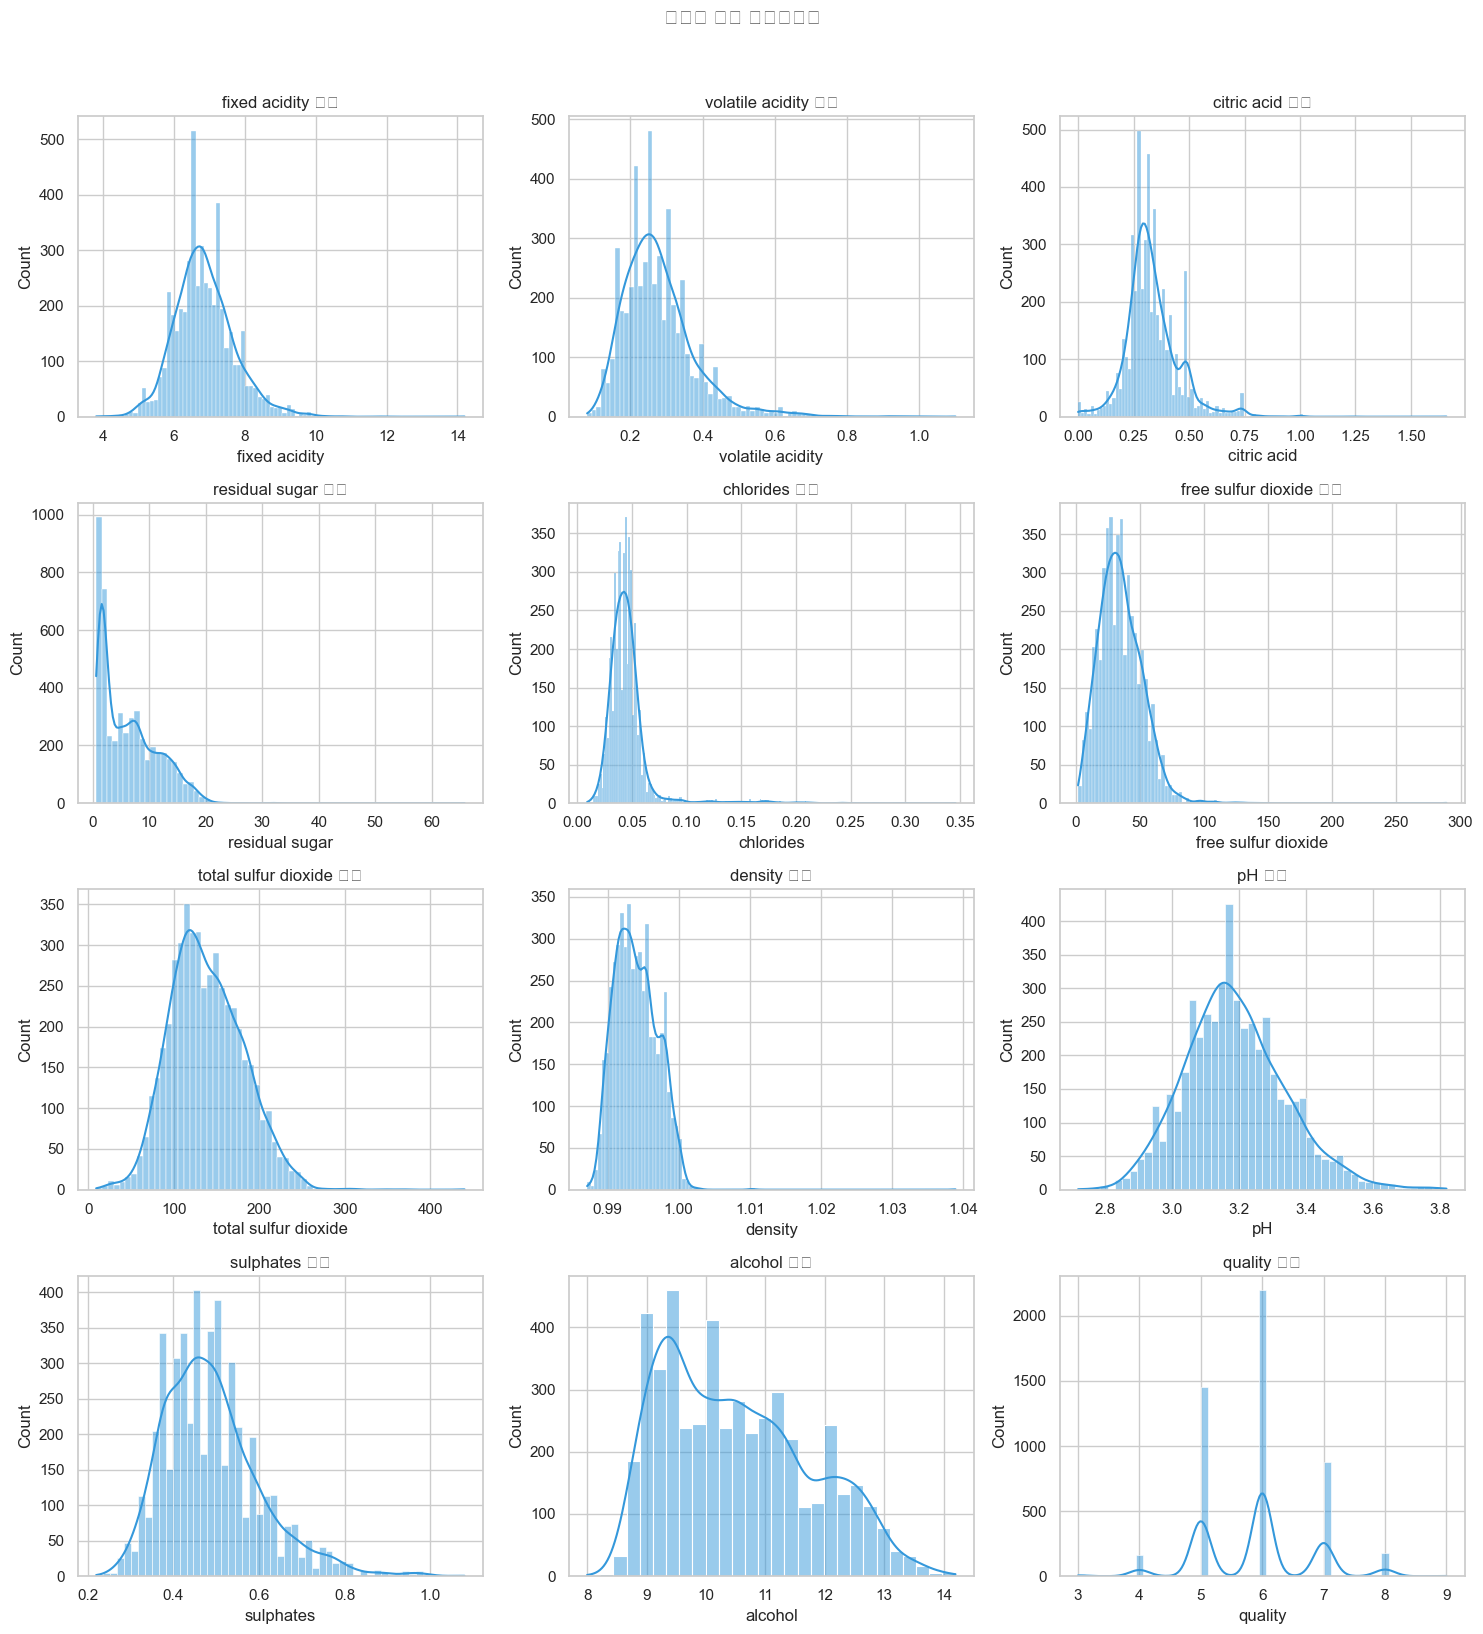

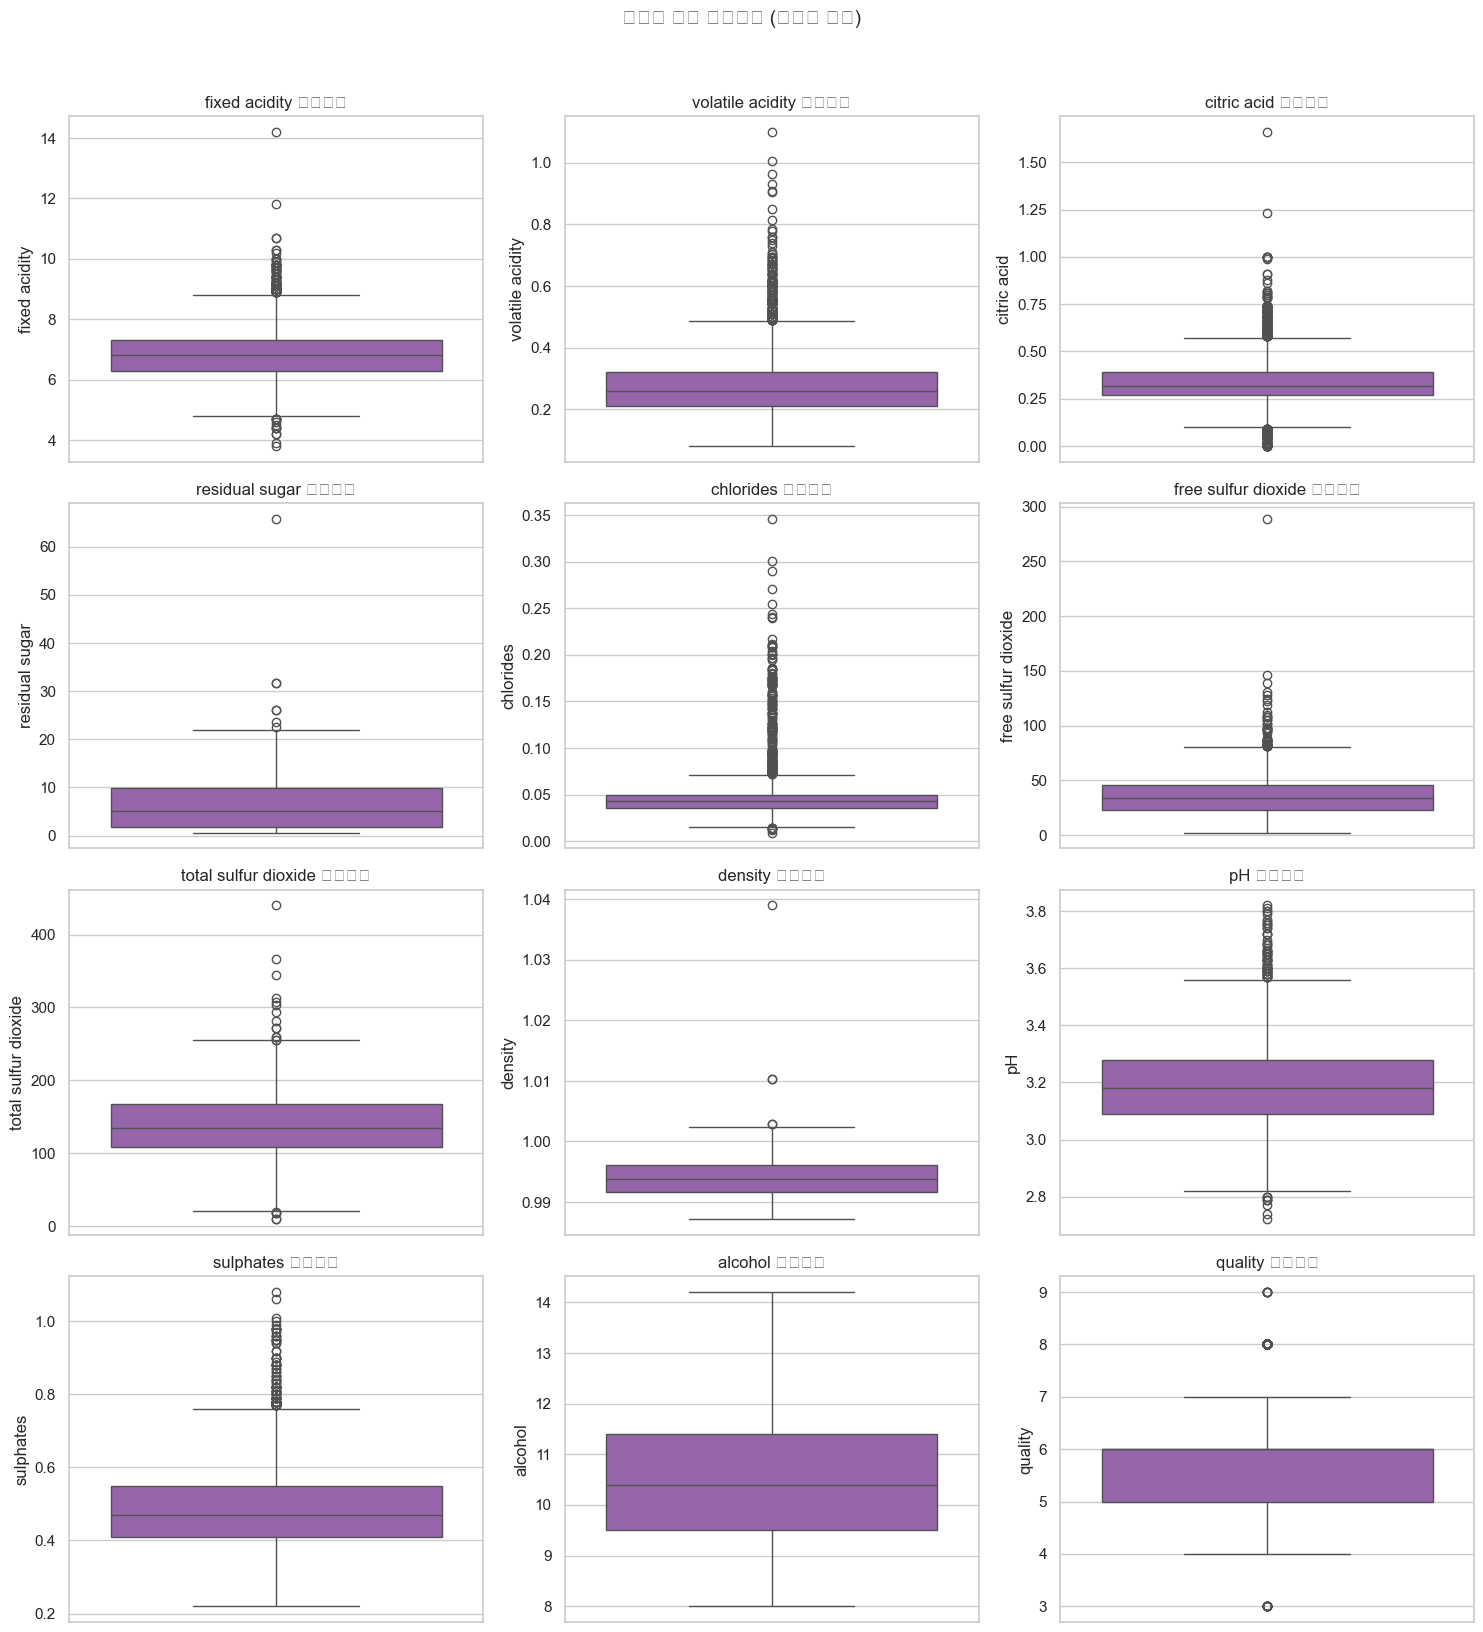

In [11]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

if not num_cols:
    print("수치형 변수가 없어 분포 분석을 건너뜁니다.")
else:
    n = len(num_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(num_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="#3498db")
        axes[i].set_title(f"{col} 분포")

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("수치형 변수 히스토그램", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    # 박스플롯
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(num_cols):
        sns.boxplot(y=df[col], ax=axes[i], color="#9b59b6")
        axes[i].set_title(f"{col} 박스플롯")

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("수치형 변수 박스플롯 (이상치 탐색)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

## 7. EDA — 범주형 변수 분석

In [12]:
cat_cols = df.select_dtypes(include=["object", "bool", "category"]).columns.tolist()
# 고유값이 너무 많은 ID성 컬럼은 시각화에서 제외
plot_cat_cols = [c for c in cat_cols if df[c].nunique() <= 30]

if not plot_cat_cols:
    print("시각화할 범주형 변수가 없습니다.")
else:
    n = len(plot_cat_cols)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cat_cols):
        order = df[col].value_counts().index
        sns.countplot(data=df, x=col, order=order, ax=axes[i], palette="Set2")
        axes[i].set_title(f"{col} 빈도")
        axes[i].tick_params(axis="x", rotation=45)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("범주형 변수 빈도 분석", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

시각화할 범주형 변수가 없습니다.


## 8. EDA — 상관관계 분석

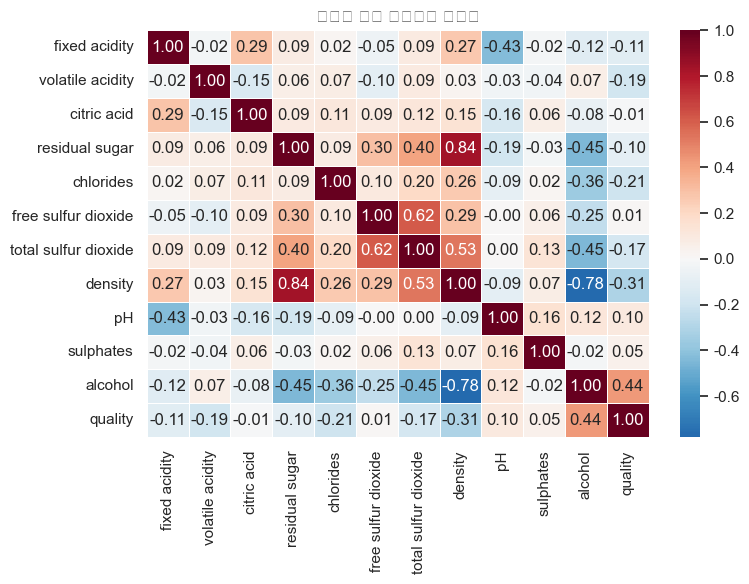


[상관계수 상위 10쌍]


,변수1,변수2,상관계수
33,residual sugar,density,0.838966
58,density,alcohol,-0.780138
45,free sulfur dioxide,total sulfur dioxide,0.615501
51,total sulfur dioxide,density,0.529881
36,residual sugar,alcohol,-0.450631
54,total sulfur dioxide,alcohol,-0.448892
65,alcohol,quality,0.435575
7,fixed acidity,pH,-0.425858
32,residual sugar,total sulfur dioxide,0.401439
43,chlorides,alcohol,-0.360189


In [13]:
if len(num_cols) >= 2:
    corr = df[num_cols].corr()

    fig, ax = plt.subplots(figsize=(max(8, len(num_cols) * 0.6), max(6, len(num_cols) * 0.5)))
    sns.heatmap(corr, annot=len(num_cols) <= 12, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, linewidths=0.5)
    ax.set_title("수치형 변수 상관계수 히트맵")
    plt.tight_layout()
    plt.show()

    # 상관계수 절댓값 상위 쌍
    corr_pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
    )
    corr_pairs.columns = ["변수1", "변수2", "상관계수"]
    corr_pairs["|상관계수|"] = corr_pairs["상관계수"].abs()
    print("\n[상관계수 상위 10쌍]")
    display(corr_pairs.sort_values("|상관계수|", ascending=False).head(10).drop(columns="|상관계수|"))
else:
    print("상관분석을 위한 수치형 변수가 2개 미만입니다.")

## 9. 타깃 변수 분석 (Churn / 불리언 컬럼 자동 탐지)

In [14]:
# 타깃 후보: 불리언 컬럼 또는 'churn', 'target', 'label' 이름의 컬럼
target_candidates = [
    c for c in df.columns
    if df[c].dtype == bool or c.lower() in {"churn", "target", "label", "y"}
]
target_col = target_candidates[0] if target_candidates else None

if target_col is None:
    print("타깃 변수(불리언/Churn)를 찾지 못했습니다. 이 섹션을 건너뜁니다.")
else:
    print(f"타깃 변수: {target_col}")
    churn_rate = df[target_col].mean() * 100
    display(Markdown(f"**{target_col} 비율**: True {df[target_col].sum()}건 / 전체 {len(df)}건 ({churn_rate:.1f}%)"))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.countplot(data=df, x=target_col, ax=axes[0], palette=["#2ecc71", "#e74c3c"])
    axes[0].set_title(f"{target_col} 분포")

    if num_cols:
        sample_num = num_cols[:6]
        melted = df[[target_col] + sample_num].melt(id_vars=target_col, var_name="feature", value_name="value")
        sns.boxplot(data=melted, x="feature", y="value", hue=target_col, ax=axes[1])
        axes[1].set_title(f"{target_col}별 주요 수치형 변수 비교")
        axes[1].tick_params(axis="x", rotation=45)
    else:
        axes[1].set_visible(False)

    plt.tight_layout()
    plt.show()

    # 범주형 변수별 타깃 비율
    if plot_cat_cols:
        compare_cols = [c for c in plot_cat_cols if c != target_col][:4]
        if compare_cols:
            n = len(compare_cols)
            fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
            if n == 1:
                axes = [axes]
            for ax, col in zip(axes, compare_cols):
                ct = pd.crosstab(df[col], df[target_col], normalize="index") * 100
                ct.plot(kind="bar", stacked=True, ax=ax, color=["#2ecc71", "#e74c3c"])
                ax.set_title(f"{col}별 {target_col} 비율(%)")
                ax.set_ylabel("비율 (%)")
                ax.legend(title=target_col)
                ax.tick_params(axis="x", rotation=45)
            plt.tight_layout()
            plt.show()

타깃 변수(불리언/Churn)를 찾지 못했습니다. 이 섹션을 건너뜁니다.


## 10. 산점도 매트릭스 (수치형 변수)

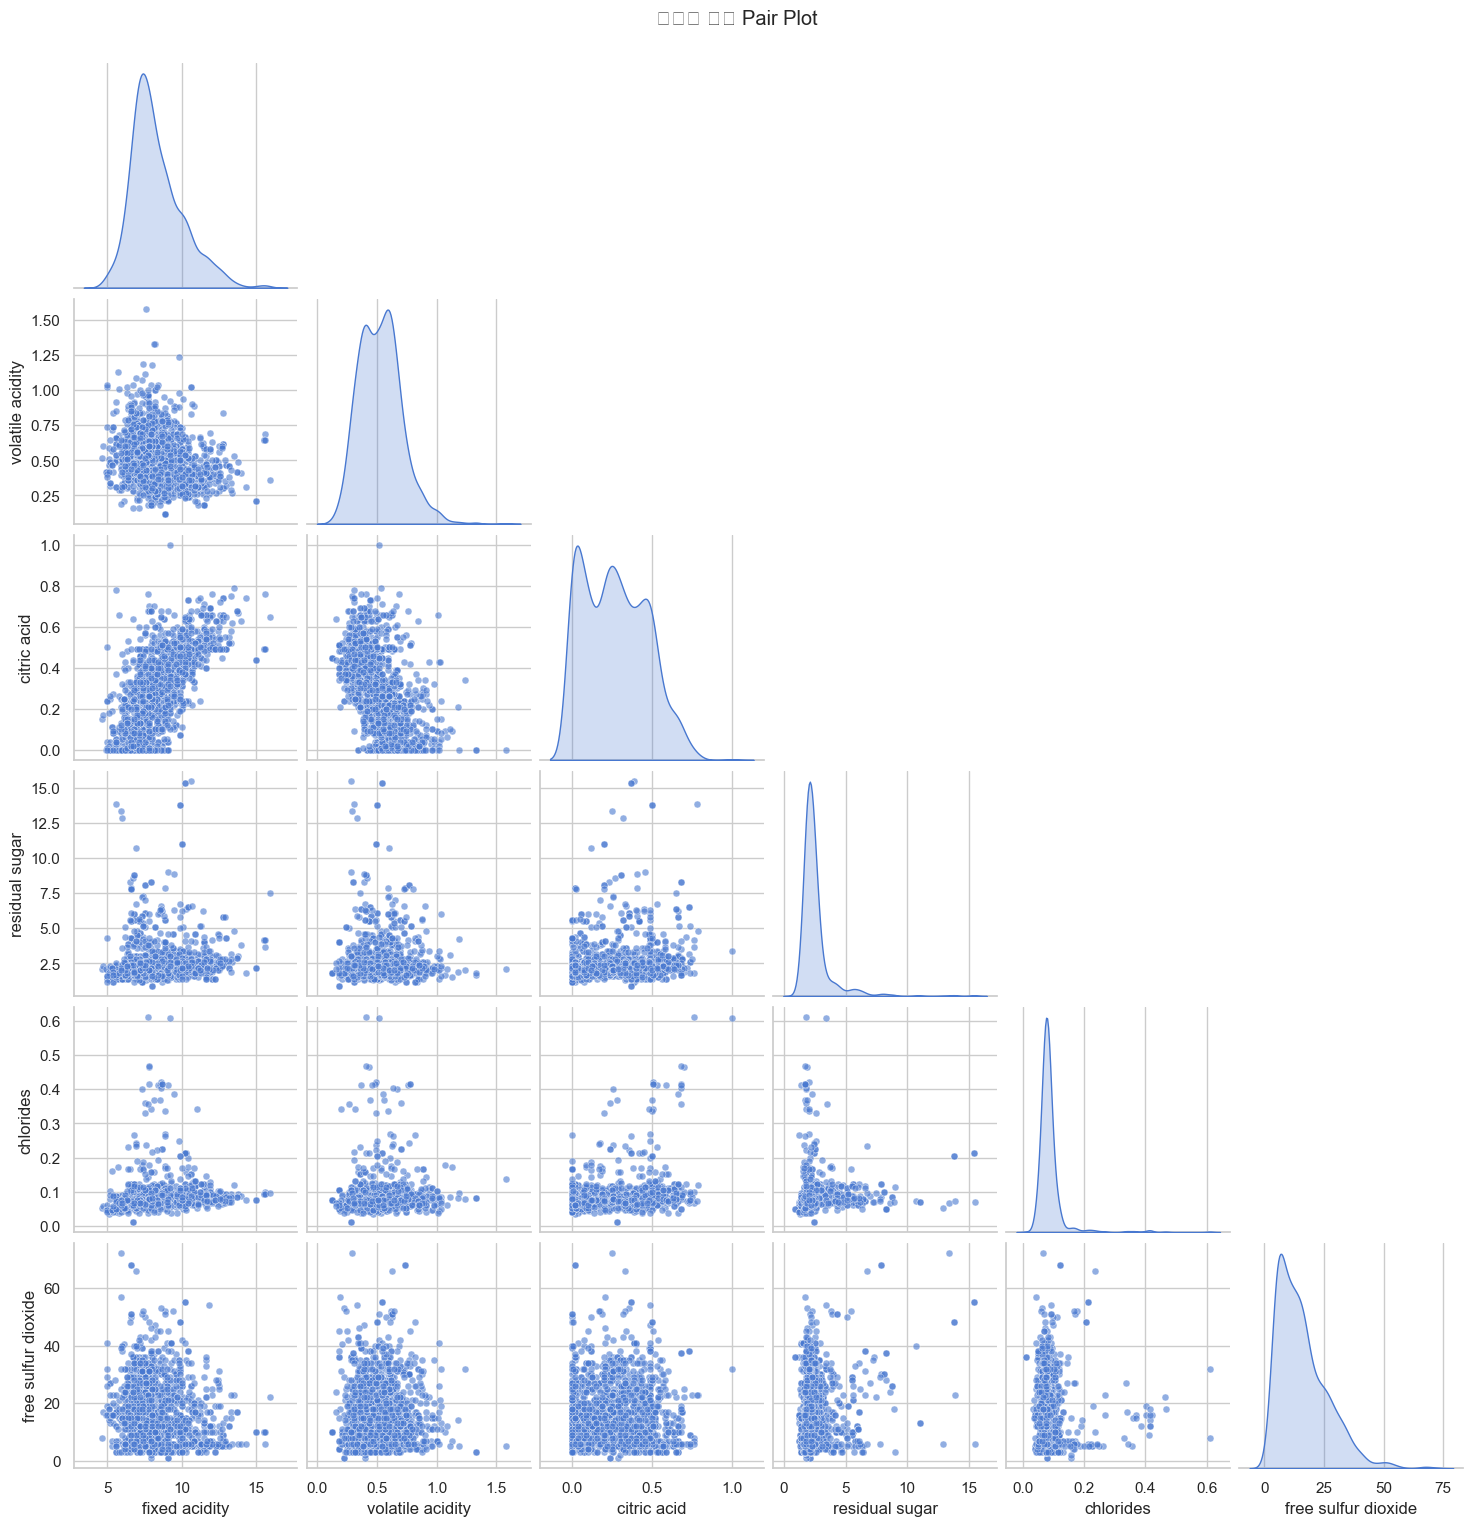

In [13]:
if len(num_cols) >= 2:
    sample_cols = num_cols[:6]
    pair_df = df[sample_cols].copy()
    if target_col and target_col in df.columns:
        pair_df[target_col] = df[target_col]
        g = sns.pairplot(pair_df, hue=target_col, diag_kind="kde", corner=True, plot_kws={"alpha": 0.6, "s": 25})
    else:
        g = sns.pairplot(pair_df, diag_kind="kde", corner=True, plot_kws={"alpha": 0.6, "s": 25})
    g.fig.suptitle("수치형 변수 Pair Plot", y=1.02)
    plt.show()
else:
    print("산점도 매트릭스를 생성할 수치형 변수가 부족합니다.")

## 11. EDA 요약 리포트

In [15]:
def generate_eda_summary(df: pd.DataFrame, source_name: str, target_col: str | None) -> str:
    lines = [
        "=" * 60,
        "EDA 요약 리포트",
        "=" * 60,
        f"파일: {source_name}",
        f"크기: {df.shape[0]:,}행 × {df.shape[1]}열",
        f"중복 행: {df.duplicated().sum():,}",
        f"결측치 있는 컬럼: {(df.isna().any()).sum()}개",
        f"수치형 컬럼: {len(df.select_dtypes(include=np.number).columns)}개",
        f"범주형 컬럼: {len(df.select_dtypes(include=['object', 'bool']).columns)}개",
    ]

    if target_col:
        rate = df[target_col].mean() * 100
        lines.append(f"타깃({target_col}) True 비율: {rate:.1f}%")

    num = df.select_dtypes(include=np.number)
    if not num.empty:
        skew = num.skew().sort_values(key=abs, ascending=False)
        lines.append("\n[왜도가 큰 수치형 변수 Top 3]")
        for col, val in skew.head(3).items():
            lines.append(f"  - {col}: {val:.2f}")

    if len(num.columns) >= 2:
        corr = num.corr()
        pairs = (
            corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack()
            .abs()
            .sort_values(ascending=False)
        )
        if not pairs.empty:
            top = pairs.index[0]
            lines.append(f"\n[가장 높은 상관관계] {top[0]} ↔ {top[1]}: {pairs.iloc[0]:.3f}")

    lines.append("\n" + "=" * 60)
    return "\n".join(lines)


summary_text = generate_eda_summary(df, source_name, target_col)
print(summary_text)

EDA 요약 리포트
파일: winequality-white.csv
크기: 4,898행 × 12열
중복 행: 937
결측치 있는 컬럼: 0개
수치형 컬럼: 12개
범주형 컬럼: 0개

[왜도가 큰 수치형 변수 Top 3]
  - chlorides: 5.02
  - volatile acidity: 1.58
  - free sulfur dioxide: 1.41

[가장 높은 상관관계] residual sugar ↔ density: 0.839

